In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import mne
from mne.minimum_norm import apply_inverse, make_inverse_operator

In [ ]:
data_file_path = "../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl"
# data_file_path = "data/20250604/processed/20250604_2_Ishii_ica_epochs.pkl"

import pickle

print(__doc__)

# pickleのEEGデータを読み込む
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs'] # エポックデータ
labels = data['labels']  # ラベル
# drop_indices = data['drop_indices']  # 除外されたエポックのインデックス

epochs_data = epochs.get_data(copy=True)  # エポックデータをリスト形式で取得
# データ型をdouble precision floatに変換
epochs_data = epochs_data.astype(np.float64)
print(epochs.info['ch_names'])  # サンプリング周波数を表示


Note: all executions are function-scoped as we do not assume the code below executes in an isolated kernel environment.

['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']


    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 63 -> 34
Estimating covariance using SHRUNK


/tmp/ipykernel_58081/2136324339.py:1: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  noise_cov = mne.compute_covariance(


Done.
Estimating covariance using EMPIRICAL
Done.
Using cross-validation to select the best estimator.
Number of samples used : 150060
log-likelihood on unseen data (descending order):
   shrunk: -92.415
   empirical: -92.417
selecting best estimator: shrunk
[done]
Computing rank from covariance with rank=None
    Using tolerance 1.9e-13 (2.2e-16 eps * 63 dim * 13  max singular value)
    Estimated rank (eeg): 34
    EEG: rank 34 computed from 63 data channels with 0 projectors


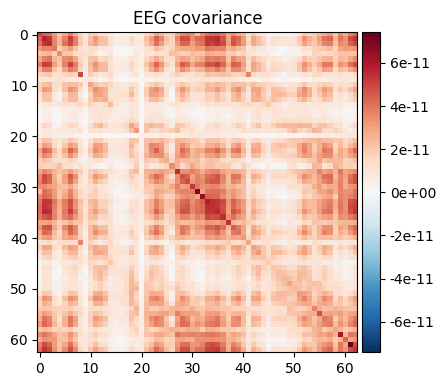

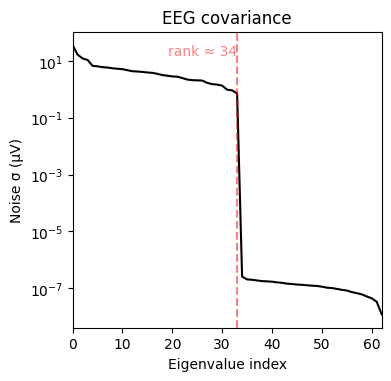

In [5]:
noise_cov = mne.compute_covariance(
    epochs, tmax=0.0, method=["shrunk", "empirical"], rank=None, verbose=True
)

fig_cov, fig_spectra = mne.viz.plot_cov(noise_cov, epochs.info)